<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/16_ddpm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative AI: Understanding Model Types

In machine learning, models can be broadly categorized into two major frameworks: **discriminative models** and **generative models**. These represent fundamentally different approaches to understanding and working with data.

## Discriminative vs. Generative Models

| Aspect | Discriminative Models | Generative Models |
|--------|----------------------|-------------------|
| **Core Objective** | Learn the boundary between classes | Learn the underlying data distribution |
| **Mathematical Focus** | Model $P(Y\|X)$ (conditional probability) | Model $P(X,Y)$ (joint probability) or $P(X)$ |
| **What They Learn** | Decision boundaries between data categories | How to generate new data samples |
| **Primary Use** | Classification and regression | Data generation and density estimation |
| **Output** | Labels, categories, or numerical predictions | New data samples resembling training distribution |
| **Typical Tasks** | Image classification, sentiment analysis, spam detection | Image generation, text synthesis, anomaly detection |
| **Common Examples** | SVMs, Neural Networks, Random Forests, Logistic Regression, Transformers (for classification), Reinforcement Learning (for policy learning) | VAEs, GANs, Diffusion Models, Normalizing Flows, Transformers (for generation), Reinforcement Learning (for world modeling) |
| **Training Process** | Often simpler and more direct optimization | Can involve complex adversarial training or likelihood estimation |
| **Inference** | Generally faster inference | Often requires iterative processes for generation |
| **Evaluation** | Clear metrics (accuracy, precision, recall, F1) | Less standardized metrics (FID, IS, log-likelihood) |
| **Sample Efficiency** | Generally more sample efficient | Often requires more training data |
| **Interpretability** | Can focus on decision boundaries | Can visualize the learned data manifold |
| **Applications** | Decision making, categorization, prediction | Content creation, data augmentation, compression |


### Discriminative Models

Discriminative models focus on learning the boundaries between different classes or predicting specific outputs given inputs. They answer the question: "Given these features, what is the most likely label or value?"

- **Strengths**:
  - Often achieve superior performance on classification tasks
  - More directly optimized for prediction accuracy
  - Generally simpler to train and deploy
  - Require fewer assumptions about the data

- **Limitations**:
  - Cannot generate new data samples
  - Don't explicitly model the data distribution
  - May struggle with imbalanced datasets
  - Limited ability to handle missing features

### Generative Models

Generative models learn to capture the entire data distribution, allowing them to generate new samples that resemble the training data. They answer the question: "How was this data generated?" or "What does typical data from this distribution look like?"

- **Strengths**:
  - Can generate novel, realistic data samples
  - Model the full data distribution
  - Can work with unlabeled data (unsupervised learning)
  - Useful for data augmentation and synthesis

- **Limitations**:
  - Often more complex to train successfully
  - May require more computational resources
  - Evaluation can be subjective or challenging
  - Sometimes less accurate for pure classification tasks

### Evolution of Generative Models
![Evolution of Generative Models](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/generative-overview.png)
The field of generative models has seen remarkable advancement over recent years:

1. **Early Probabilistic Models (pre-2010)**: 
   - Hidden Markov Models and Naive Bayes
   - Simple yet effective for structured data
   - Limited expressiveness for complex distributions

2. **Deep Belief Networks & Restricted Boltzmann Machines (2006-2014)**:
   - First successful deep generative models
   - Used layer-by-layer pretraining
   - Challenged by difficult training dynamics and evaluation

3. **Variational Autoencoders (VAEs) (2013)**:
   - Introduced trainable deep generative models with clear probabilistic foundations
   - Combined variational inference with neural networks
   - Enabled efficient inference and generation
   - Often produce blurry samples due to their objective function

4. **Generative Adversarial Networks (GANs) (2014)**:
   - Revolutionary approach using adversarial training between generator and discriminator
   - Produced remarkably sharp samples
   - Suffered from training instability, mode collapse, and evaluation challenges
   - Led to numerous architectural variants (DCGAN, StyleGAN, BigGAN)

5. **Autoregressive Models (2016-present)**:
   - Generate data sequentially, one element at a time
   - Examples include PixelCNN, PixelRNN, and Transformer-based models like GPT
   - Exact likelihood evaluation but slow sequential generation
   - Dominated NLP applications through transformer architectures

6. **Flow-based Models (2016-present)**:
   - Based on invertible transformations with exact likelihood computation
   - Models include RealNVP, Glow, and Flow++
   - Allow both efficient sampling and density estimation
   - Often trade simplicity of flows for expressiveness

7. **Diffusion Models (2020-present)**:
   - Current state-of-the-art for many generation tasks
   - Based on gradually removing noise from a signal
   - Stable training with high sample quality
   - Used in commercial systems like DALL-E 2, Stable Diffusion, and Midjourney

8. **Consistency Models (2023-present)**:
   - Further refinement of diffusion approaches focusing on sampling efficiency
   - Enable one-step or few-step generation
   - Maintain quality while dramatically reducing computation

Each generation of models has addressed limitations of previous approaches while opening new possibilities for generative AI applications.

## Comparison of Major Generative Architectures

Understanding the strengths and limitations of different generative architectures helps contextualize why diffusion models have become dominant in certain domains.

![Comparison of Generative Models](https://miro.medium.com/v2/resize:fit:1400/1*9sV5tj6XJ8M23FAa_jzLqQ.png)

| Architecture | Core Mechanism | Strengths | Limitations | Key Applications |
|--------------|----------------|-----------|-------------|------------------|
| **VAEs** | Encode data to latent distribution, then decode | - Stable training<br>- Explicit latent space<br>- Fast sampling | - Blurry samples<br>- Limited expressiveness | - Representation learning<br>- Feature extraction<br>- Anomaly detection |
| **GANs** | Adversarial game between generator and discriminator | - Sharp, realistic samples<br>- Fast sampling<br>- Efficient architecture | - Training instability<br>- Mode collapse<br>- No likelihood estimation | - Photorealistic imagery<br>- Style transfer<br>- Data augmentation |
| **Autoregressive** | Sequential generation conditioned on previous elements | - Tractable likelihood<br>- Strong at capturing dependencies<br>- Natural for sequential data | - Slow sampling<br>- No explicit latent space | - Text generation<br>- Speech synthesis<br>- Music generation |
| **Flow Models** | Series of invertible transformations | - Exact likelihood computation<br>- Fast sampling<br>- Invertible mappings | - Architecture constraints<br>- Complex designs for high performance | - Density estimation<br>- Anomaly detection<br>- Variational inference |
| **Diffusion Models** | Progressive denoising from random noise | - High sample quality<br>- Training stability<br>- Flexible conditioning | - Slow sampling process<br>- Compute intensive | - Image generation<br>- Audio synthesis<br>- 3D content creation |

### Latent Space Visualization

Different generative architectures organize their latent spaces in distinct ways, which impacts how they represent and manipulate data:

![Latent Space Comparison](https://i.imgur.com/8KvUfJL.png)

- **VAEs**: Enforce a structured (typically Gaussian) latent space that enables smooth interpolation but may lose information
- **GANs**: Implicitly learn a latent space mapping to the data manifold, often allowing meaningful semantic operations
- **Diffusion Models**: Operate in the data space directly, with intermediate steps representing progressively noisier versions of data

This difference in latent representation explains many of the practical differences in generation quality, editability, and sampling behavior.

# Diffusion Models

Diffusion models are a powerful class of generative models that have recently achieved state-of-the-art results in generating high-quality images, audio, and other data types. These models work by gradually adding noise to data and then learning to reverse this process, offering a novel approach to generation that differs fundamentally from GANs and VAEs.

## Conceptual Overview

Diffusion models operate based on two primary processes:

1. **Forward Process (Diffusion)**: Gradually adds Gaussian noise to the data through a fixed sequence of steps until it becomes pure noise following a standard normal distribution. This process systematically destroys structure in the data.

2. **Reverse Process (Denoising)**: Learns to gradually remove noise to recover the original data distribution, starting from random noise. This is the generative process that creates new samples.

![Diffusion Process](https://theaisummer.com/static/d007d60f773b61f4585cbec3869490d5/a878e/score-sde.png)

The key insight behind diffusion models is that while destroying information (adding noise) is straightforward and can be defined analytically, the model learns the challenging task of restoring information from noise. This separation creates a more stable training process compared to adversarial methods like GANs.

### Intuitive Understanding

Think of the forward process as slowly dissolving an image in acid (noise) over time until nothing recognizable remains. The reverse process then learns how to reconstruct the image by understanding how different elements of the image dissolve at different rates and in different patterns.

![Diffusion Step by Step](https://d33wubrfki0l68.cloudfront.net/54c4449f1cad42913a0718bb16182452df2f3874/3c816/assets/posts/annotated-diffusion/denoising_animation.gif)

This animation shows how a diffusion model progressively denoises an image, starting from pure noise and gradually revealing structure until producing a clean sample. The process moves from high entropy (disorder) to low entropy (ordered structure) by iteratively applying learned denoising operations.

This approach allows the model to learn the complex structure and details of the data distribution in a progressive manner, focusing on different levels of detail at different denoising steps:

## Mathematical Foundation

### Forward Process

The forward diffusion process is defined as a Markov chain that gradually adds Gaussian noise to the data:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I)$$

where $\beta_t$ is a variance schedule that controls the noise level at each step $t$. This schedule is typically designed to start small and increase over time, allowing for gradual noise addition.

An important mathematical property allows us to sample $x_t$ directly from $x_0$ without going through all intermediate steps (called the reparameterization trick):

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) I)$$

where $\bar{\alpha}_t = \prod_{i=1}^{t} (1 - \beta_i)$.

This means we can directly compute any noised version $x_t$ given the original data $x_0$, which significantly simplifies the training process.

### Reverse Process

The goal is to learn the reverse process, which gradually denoises the data:

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

The neural network is trained to predict the parameters of this distribution. In practice, the model is often simplified to predict either:

1. The noise component added at step $t$
2. The clean data $x_0$ directly
3. The mean $\mu_\theta$ of the reverse process distribution

For most implementations, predicting the added noise has proven most effective and stable.

### Interactive Demonstration: Forward Diffusion Process

Let's visualize how the forward diffusion process gradually destroys the structure of data by adding noise. We'll use a simple 2D pattern (a Gaussian blob) as our "image" and apply the noise schedule defined mathematically above.

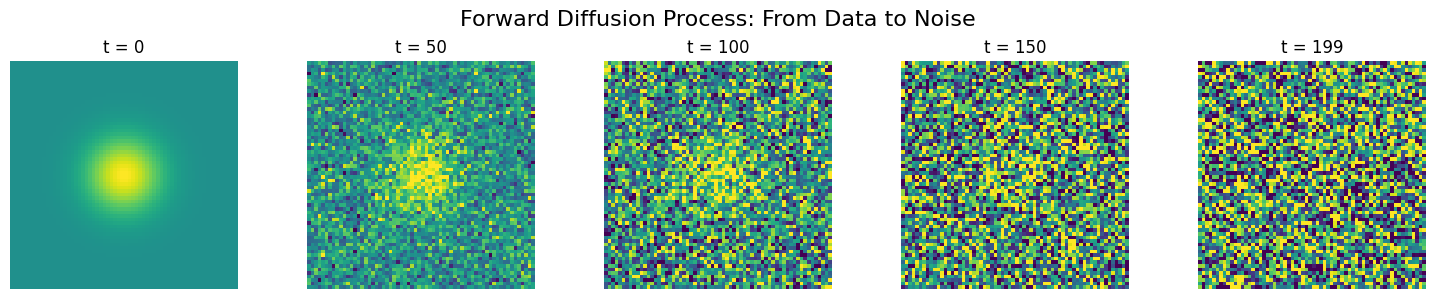

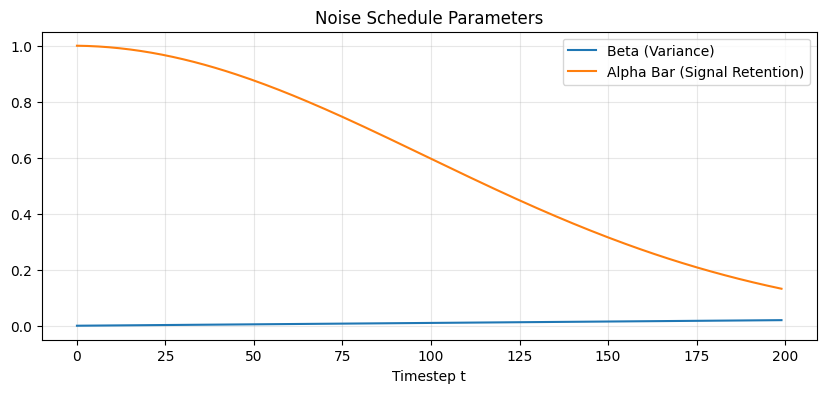

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Noise Schedule
# We use a linear beta schedule as proposed in the original DDPM paper
T = 200  # Total number of timesteps
beta_start = 0.0001
beta_end = 0.02
beta = np.linspace(beta_start, beta_end, T)

# Pre-calculate alpha and alpha_bar (cumulative product)
alpha = 1. - beta
alpha_bar = np.cumprod(alpha)

def forward_diffusion(x_0, t):
    """
    Simulate the forward diffusion process at timestep t using the reparameterization trick.
    
    Args:
        x_0: Original data (image)
        t: Timestep (0 to T-1)
        
    Returns:
        x_t: Noisy version of x_0 at timestep t
    """
    if t == 0:
        return x_0
    
    # Sample noise from standard normal distribution
    epsilon = np.random.randn(*x_0.shape)
    
    # Apply the reparameterization trick:
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
    mean = np.sqrt(alpha_bar[t]) * x_0
    std = np.sqrt(1 - alpha_bar[t])
    
    return mean + std * epsilon

# 2. Create a synthetic "image"
# We'll create a simple 2D Gaussian blob pattern
x, y = np.meshgrid(np.linspace(-3, 3, 64), np.linspace(-3, 3, 64))
x_0 = np.exp(-(x**2 + y**2))  # Gaussian blob

# 3. Visualize the process at different timesteps
timesteps_to_show = [0, 50, 100, 150, 199]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t in enumerate(timesteps_to_show):
    x_t = forward_diffusion(x_0, t)
    
    # Plotting
    axes[i].imshow(x_t, cmap='viridis', vmin=-1, vmax=1)
    axes[i].set_title(f"t = {t}")
    axes[i].axis('off')

plt.suptitle("Forward Diffusion Process: From Data to Noise", fontsize=16)
plt.tight_layout()
plt.show()

# 4. Visualize the Noise Schedule
plt.figure(figsize=(10, 4))
plt.plot(beta, label='Beta (Variance)')
plt.plot(alpha_bar, label='Alpha Bar (Signal Retention)')
plt.title("Noise Schedule Parameters")
plt.xlabel("Timestep t")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Conceptual Demonstration: The Denoising Task

The goal of the diffusion model is to reverse the process. Mathematically, if we know the exact noise $\epsilon$ that was added to create $x_t$, we can recover the original image $x_0$ (or at least a cleaner version $x_{t-1}$).

The code below demonstrates this:
1. We take a noisy image $x_t$.
2. If we subtract the **correct** noise (simulating a perfect model), we recover the original structure.
3. If we subtract **random** noise (simulating an untrained model), we get garbage.

This illustrates why we train a neural network to predict the specific noise instance added to the image.

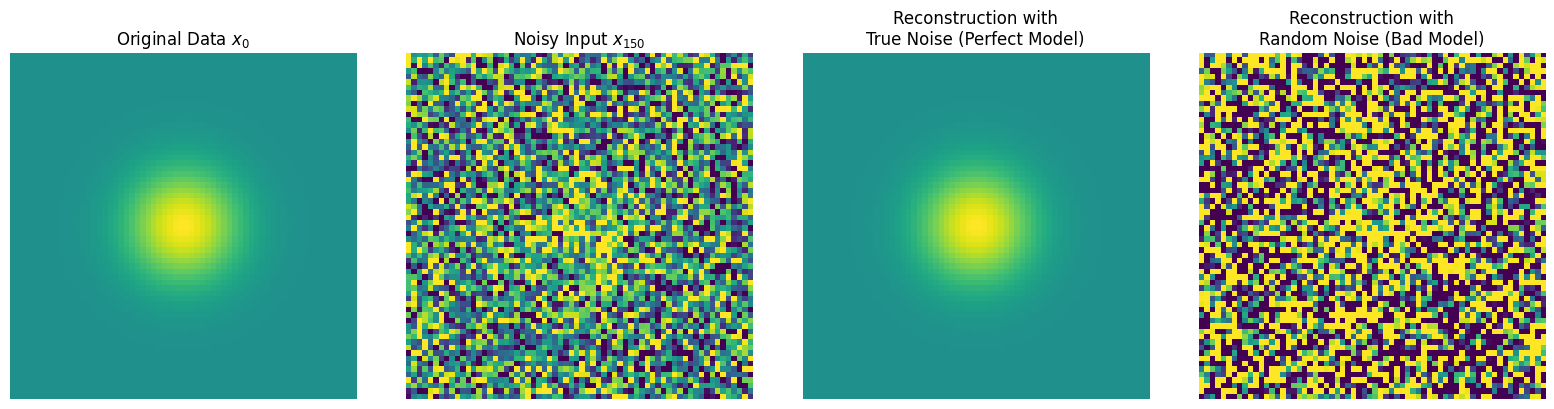

In [2]:
def estimate_original(x_t, t, predicted_noise):
    """
    Estimate x_0 from x_t given the noise prediction.
    Formula: x_0 = (x_t - sqrt(1 - alpha_bar_t) * epsilon) / sqrt(alpha_bar_t)
    """
    if t == 0:
        return x_t
        
    alpha_bar_t = alpha_bar[t]
    return (x_t - np.sqrt(1 - alpha_bar_t) * predicted_noise) / np.sqrt(alpha_bar_t)

# 1. Create a specific noisy instance
t_demo = 150
noise_true = np.random.randn(*x_0.shape)

# Create x_t manually
mean = np.sqrt(alpha_bar[t_demo]) * x_0
std = np.sqrt(1 - alpha_bar[t_demo])
x_t_demo = mean + std * noise_true

# 2. Attempt reconstruction

# Case A: Perfect Model (We know the true noise)
x_0_perfect = estimate_original(x_t_demo, t_demo, noise_true)

# Case B: Untrained Model (Predicts random noise)
noise_random = np.random.randn(*x_0.shape)
x_0_bad = estimate_original(x_t_demo, t_demo, noise_random)

# 3. Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(x_0, cmap='viridis', vmin=-1, vmax=1)
axes[0].set_title("Original Data $x_0$")

axes[1].imshow(x_t_demo, cmap='viridis', vmin=-1, vmax=1)
axes[1].set_title(f"Noisy Input $x_{{{t_demo}}}$")

axes[2].imshow(x_0_perfect, cmap='viridis', vmin=-1, vmax=1)
axes[2].set_title("Reconstruction with\nTrue Noise (Perfect Model)")

axes[3].imshow(x_0_bad, cmap='viridis', vmin=-1, vmax=1)
axes[3].set_title("Reconstruction with\nRandom Noise (Bad Model)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Training Objective

The training objective for diffusion models is derived from variational inference principles. While the full objective involves complex terms related to the ELBO (Evidence Lower Bound), it can be simplified to a more tractable form.

### Simplified Objective

The most common simplified objective is the noise prediction objective:

$$L_{simple} = \mathbb{E}_{t, x_0, \epsilon} \left[ ||\epsilon - \epsilon_\theta(x_t, t)||^2 \right]$$

where:
- $\epsilon$ is the actual noise added during the forward process
- $\epsilon_\theta$ is the model's prediction of that noise
- $t$ is randomly sampled from $\{1, 2, ..., T\}$ during training
- $x_0$ is a sample from the training data

This objective asks the model to predict what noise was added to create $x_t$ from $x_0$. When the model can accurately predict this noise, it can effectively reverse the noise addition process during sampling.

### Weighting Strategies

In practice, various weighting strategies have been proposed to improve training stability and sample quality:

- **Original DDPM weighting**: $L = ||\epsilon - \epsilon_\theta(x_t, t)||^2$
- **Improved DDPM weighting**: $L = ||w(t) \cdot (\epsilon - \epsilon_\theta(x_t, t))||^2$

where $w(t)$ is a weighting function that emphasizes certain timesteps.

## Model Architecture

The backbone of most diffusion models is a U-Net architecture with several important modifications:

1. **Time Embedding**: Since the model needs to know which denoising step it's performing, the timestep $t$ is embedded and injected into the network.

2. **Attention Mechanisms**: Self-attention layers are typically incorporated to capture global context, which is crucial for coherent generation.

3. **Residual Connections**: Extensive use of residual connections helps information flow through the deep network.

4. **Conditioning Mechanisms**: For conditional generation (e.g., based on class labels or text), various conditioning techniques are employed, often using cross-attention mechanisms.

The most successful diffusion models typically employ large U-Net architectures with hundreds of millions of parameters, though smaller models can still produce impressive results for specific domains.

### Detailed Architecture Diagram

The diagram below illustrates the key components of a typical diffusion model architecture:

![DDPM U-Net Architecture](https://theaisummer.com/static/ecb7a31540b18a8cbd18eedb446b468e/40ffe/diffusion-models.png)

Key architectural elements include:

1. **Encoder Path**: Progressively reduces spatial dimensions while increasing feature channels
   - Uses strided convolutions or downsampling blocks
   - Captures hierarchical features at multiple scales

2. **Timestep Embedding**: Encodes the denoising timestep
   - Usually implemented with sinusoidal position embeddings
   - Injected at multiple points in the network via adaptive normalization or addition

3. **Attention Blocks**: Captures global context
   - Self-attention mechanisms help model long-range dependencies
   - Particularly important for coherent image generation

4. **Decoder Path**: Progressively increases spatial dimensions
   - Uses transposed convolutions or upsampling blocks
   - Skip connections from encoder preserve spatial information

5. **Conditioning Inputs**: Optional pathways for controlling generation
   - Can include class embeddings, text features, or other conditioning signals
   - Often incorporated through cross-attention or adaptive normalization

## Sampling Process

Once trained, generating new samples with a diffusion model involves the following steps:

1. **Start with pure noise**: Sample $x_T \sim \mathcal{N}(0, I)$

2. **Iterative denoising**: For $t$ from $T$ down to 1:
   - Predict noise or clean data component using the model
   - Compute the parameters of $p_\theta(x_{t-1}|x_t)$
   - Sample $x_{t-1}$ from this distribution

3. **Return final sample**: $x_0$ is the generated sample

This sampling process moves gradually from pure noise to a coherent sample from the learned data distribution. The step size and number of steps significantly impact both quality and computational efficiency.

## Key Variants of Diffusion Models

### DDPM (Denoising Diffusion Probabilistic Models)
- The original formulation introduced by Ho et al. (2020)
- Uses a fixed variance schedule and Markovian sampling process
- Excellent quality but requires many sampling steps (typically 1000)
- Forms the foundation for most subsequent diffusion models

### DDIM (Denoising Diffusion Implicit Models)
- Extends DDPM with a non-Markovian process that allows for deterministic sampling
- Enables faster sampling with fewer steps (10-50 steps often sufficient)
- Maintains high sample quality even with accelerated sampling
- Introduces the concept of "skip connections" between timesteps

### Latent Diffusion Models (LDMs)
- Apply diffusion in a compressed latent space instead of pixel space
- Use an autoencoder to reduce the dimensionality of the data before diffusion
- Significantly more efficient for high-resolution images (10-100x speedup)
- Used in Stable Diffusion for text-to-image generation
- Enables practical applications on consumer hardware

### Score-Based Generative Models
- Alternative mathematical formulation using score matching principles
- Models the gradient of the log probability density (score function)
- Shown to be equivalent to diffusion models under certain conditions
- Often uses stochastic differential equations (SDEs) for sampling
- Provides a continuous-time perspective on the diffusion process

## Conditioning Techniques

Diffusion models can be conditioned on various inputs to control generation. The primary conditioning methods include:

### Class Conditioning
- Used to generate samples from specific classes or categories
- Class labels are typically embedded and combined with timestep embeddings
- Can be implemented via addition, concatenation, or conditional batch normalization
- Enables controlled generation of specific categories

### Text Conditioning
- Used in text-to-image models like Stable Diffusion, DALL-E 2, and Midjourney
- Leverages pre-trained text encoders (like CLIP or T5) to extract text embeddings
- Typically injects text information via cross-attention mechanisms
- Allows for rich, detailed control over generation process
- Can be combined with other conditioning techniques

### Image Conditioning
- Used for image-to-image translation, inpainting, and super-resolution
- Input image can be incorporated through concatenation or more sophisticated fusion
- Enables applications like style transfer, colorization, and image editing
- Often combined with masking for targeted image manipulation

### Layout Conditioning
- Conditions generation on spatial layouts, bounding boxes, or segmentation maps
- Useful for controlled scene generation with specific object arrangements
- Often combines spatial information with semantic labels

## Applications of Diffusion Models

### Image Generation and Manipulation
- Text-to-image synthesis (Stable Diffusion, DALL-E 2, Midjourney)
- High-resolution image creation (up to gigapixel images)
- Image editing, inpainting, and outpainting
- Style transfer and domain adaptation
- Synthetic data generation for training other models

### Audio Generation
- Speech synthesis and voice cloning (AudioLM, VALL-E)
- Music generation and instrument synthesis
- Sound effects creation and audio enhancement
- Text-to-speech with emotional control
- Audio inpainting and restoration

### Video Generation
- Text-to-video synthesis (Imagen Video, Make-A-Video, Gen-2)
- Video prediction and future frame generation
- Video editing and manipulation
- Motion transfer and video style transfer
- Slow-motion generation and frame interpolation

### 3D Content Creation
- Text-to-3D model generation (DreamFusion, Magic3D)
- 3D asset creation for games and virtual environments
- Neural radiance field (NeRF) generation
- 3D completion from partial observations
- Texture synthesis for 3D models

### Scientific Applications
- Protein structure generation and drug discovery
- Molecule design and optimization
- Material property prediction and design
- Weather forecasting and climate modeling
- Medical image synthesis and enhancement

## Advantages and Challenges

### Advantages
- **High Quality**: Produces some of the highest quality generative outputs across domains
- **Training Stability**: More stable training compared to GANs, without mode collapse issues
- **Sample Diversity**: Naturally generates diverse outputs without additional mechanisms
- **Flexible Conditioning**: Easily adaptable to various conditioning inputs
- **Theoretical Foundation**: Well-understood probabilistic foundation with clear optimization objectives
- **Controllability**: Allows for fine-grained control over the generation process
- **Adaptability**: Can be applied to multiple data modalities with minimal architecture changes

### Challenges
- **Computational Efficiency**: Sampling can be slow due to the sequential nature of the process
- **Resource Requirements**: Training high-quality models requires significant computational resources
- **Hyperparameter Sensitivity**: Performance can be affected by choice of noise schedule and model architecture
- **Evaluation Metrics**: Difficult to quantitatively evaluate generative performance
- **Mode Coverage vs. Fidelity**: Trade-off between covering all modes and sample quality
- **Long-Range Coherence**: Can struggle with global coherence in very large outputs
- **Ethical Considerations**: Potential for generating misleading or harmful content

## Recent Advances and Future Directions

### Sampling Efficiency Improvements
- **Consistency Models**: Single-step generation with distillation from diffusion models
- **Diffusion Distillation**: Training smaller, faster models that mimic diffusion outputs
- **Flow Matching**: Alternative formulation that can enable faster sampling
- **Progressive Distillation**: Gradually reducing the number of required sampling steps

### Architectural Innovations
- **Rectified Flow**: Combining flow-based models with diffusion principles
- **DiT (Diffusion Transformers)**: Replacing U-Nets with transformer architectures
- **Mamba-based Diffusion**: Using state space models instead of attention mechanisms
- **Mixture of Experts**: Specialized sub-networks for different parts of the denoising process

### Multi-Modal Applications
- **Video Diffusion Models**: Extending image diffusion to the temporal dimension
- **Multi-Modal Conditioning**: Combining text, image, audio, and video inputs
- **3D-Aware Generation**: Models that understand 3D structure from 2D training
- **Cross-Modal Generation**: Converting between different modalities (e.g., text-to-audio)

### Personalization Techniques
- **DreamBooth**: Few-shot personalization of text-to-image models
- **LoRA/Custom Diffusion**: Parameter-efficient fine-tuning methods
- **Textual Inversion**: Learning new concepts from just a few examples
- **Concept Libraries**: Reusable personalized concepts across generations

## References and Further Reading

### Foundation Papers
- Ho, J., et al. (2020). [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239). NeurIPS.
- Song, J., et al. (2020). [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502). ICLR.
- Rombach, R., et al. (2022). [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752). CVPR.
- Dhariwal, P., & Nichol, A. (2021). [Diffusion Models Beat GANs on Image Synthesis](https://arxiv.org/abs/2105.05233). NeurIPS.
- Song, Y., & Ermon, S. (2019). [Generative Modeling by Estimating Gradients of the Data Distribution](https://arxiv.org/abs/1907.05600). NeurIPS.

### Recent Advances
- Karras, T., et al. (2022). [Elucidating the Design Space of Diffusion-Based Generative Models](https://arxiv.org/abs/2206.00364).
- Song, Y., et al. (2023). [Consistency Models: Learning SDEs from Diffusion Models](https://arxiv.org/abs/2303.01469).
- Peebles, W., & Xie, S. (2023). [Scalable Diffusion Models with Transformers](https://arxiv.org/abs/2212.09748).
- Ruiz, N., et al. (2023). [DreamBooth: Fine Tuning Text-to-Image Diffusion Models for Subject-Driven Generation](https://arxiv.org/abs/2208.12242).

### Books and Tutorials
- Luo, C. (2022). [Understanding Diffusion Models: A Unified Perspective](https://arxiv.org/abs/2208.11970).
- Weng, L. (2021). [What are Diffusion Models?](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)

### Implementations and Resources
- [HuggingFace Diffusers Library](https://github.com/huggingface/diffusers)
- [Stable Diffusion](https://github.com/CompVis/stable-diffusion)
- [Annotated Diffusion Model Implementation](https://huggingface.co/blog/annotated-diffusion)